In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4)

# Exercise 08:  Linear Regression

### The advertising data

To help you get started in these exercise, here's what we did with the advertising data.

What are the examples?

- Each example represents a product in a given market with a total of 200 in the dataset.

What are the features?

- **TV:** advertising dollars spent on TV ads 
- **radio:** advertising dollars spent on radio ads
- **newspaper:** advertising dollars spent on newspaper ads

All expenditures are in thousands of dollars.

What are the labels?

- **sales:** sales of a product in a given market (in thousands of widgets)

At this point we will focus on one of the features, TV advertising.

In [4]:
# read data into a pandas DataFrame
import pandas as pd
data = pd.read_csv('https://www.statlearning.com/s/Advertising.csv', 
                   index_col=0)
data.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [5]:
# create feature matrix and vector of labels
X = data[['TV']].values
y = data['sales'].values
X.shape, y.shape

((200, 1), (200,))


### Linear regression on the advertising data

Next, we will use scikit-learn to perform linear regression to predict sales:

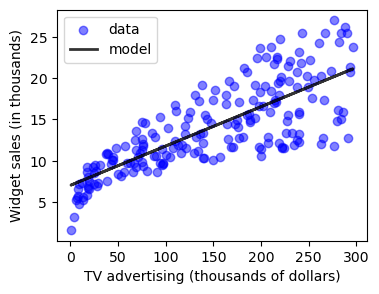

In [7]:
from sklearn.linear_model import LinearRegression

# instantiate, fit, and predict:
linreg = LinearRegression()
linreg.fit(X, y)
y_pred = linreg.predict(X)

# plot the reslts
fig = plt.figure(figsize=(4,3))
ax  = fig.add_subplot(111)

ax.scatter(X, y,  color='blue', alpha=0.5, label = 'data')
ax.plot(X, y_pred, color='black', alpha=0.8,linewidth=2, label = 'model')
ax.set_xlabel('TV advertising (thousands of dollars)')
ax.set_ylabel('Widget sales (in thousands)')
ax.legend(loc="best");

### Exercise:  toy data

Create one-dimensional regression data using scikit-learn's [make_regression](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html#sklearn.datasets.make_regression).  Use linear regression to create a model and plot the resulting fitted line.  Evaluate the quality of the model on a separate test set using the Root-Mean-Square Error (RMSE) which is the square root of the mean of the squared errors:

$$\mathrm{RMSE} = \sqrt{\frac 1N\sum_{i=1}^N(y_i-\hat{y}_i)^2}$$

Compare the RMSE on the training set with the RMSE on the test set.
In implementing the RMSE calculation, avoid using a for loop!

Note that `make_regression` has a `noise` parameter that controls the level of noise in the labels (it sets its standard deviation).  Choose an appropriate value so the data "looks noisy" when plotted.

RMSE on training:  90.2800518141121
RMSE on test:  101.49586977957105


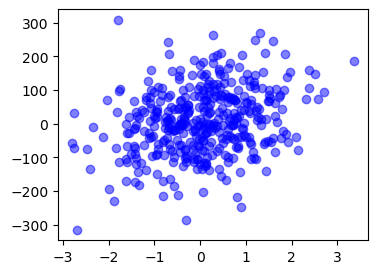

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# create data
noise_level = 100
X, y = make_regression(400, 1, noise=noise_level)

# plot the data
fig = plt.figure(figsize=(4,3))
ax = fig.add_subplot(111)
ax.scatter(X, y,  color='blue', alpha=0.5, label = 'data')

# split into train / test using sklearn.model_selection.train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# fit model
model = LinearRegression()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# compute RMSE on train / test sets
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE on training: ", train_rmse)
print("RMSE on test: ", test_rmse)

### Exercise:  Susceptibility to noise

Linear regression models can be impacted by noise in the data.  This exercise is designed to explore that.

In the following toy problem, change the label of one of the data points to mimic a *data error* or other form of noise.  After doing so, train another linear regression model, and plot the resulting model.  Describe the effect on the regression line as a result of modifying the label.

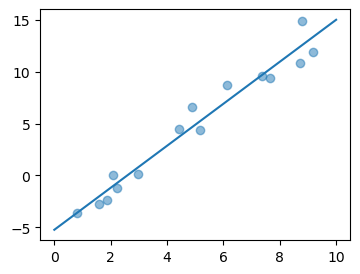

In [25]:
from sklearn.linear_model import LinearRegression

rng = np.random.RandomState(5)
x = 10 * rng.rand(15)
y = 2 * x - 5 + rng.randn(15)

model = LinearRegression()
model.fit(x[:, np.newaxis], y)

xs = np.linspace(0, 10, 1000)
ys = model.predict(xs[:, np.newaxis])

plt.figure(figsize=(4, 3))
plt.scatter(x, y, alpha=0.5)
plt.plot(xs, ys);


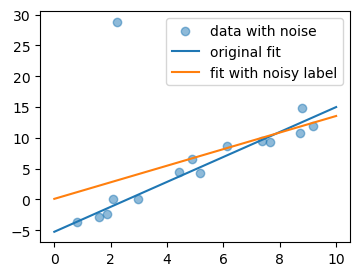

In [24]:
# copy the above code cell and change one of the data points 
# to illustrate the effect of errors  on the resulting model
from sklearn.linear_model import LinearRegression


rng = np.random.RandomState(5)
x = 10 * rng.rand(15)
y = 2 * x - 5 + rng.randn(15)

# fit original model
model = LinearRegression()
model.fit(x[:, np.newaxis], y)
xs = np.linspace(0, 10, 1000)
ys = model.predict(xs[:, np.newaxis])

# noise
y_noisy = y.copy()
y_noisy[0] = y_noisy[0] + 30  # add noise to one point

# noisy model
model_noisy = LinearRegression()
model_noisy.fit(x[:, np.newaxis], y_noisy)
ys_noisy = model_noisy.predict(xs[:, np.newaxis])

# plot
plt.figure(figsize = (4,3))
plt.scatter(x, y_noisy, alpha = 0.5, label = "data with noise")
plt.plot(xs, ys, label = "original fit")
plt.plot(xs, ys_noisy, label = "fit with noisy label")
plt.legend()
plt.show()

**You can clearly see that the noisy data messed with the classifier just a little bit, making the line slightly different than the original fit.**